# Macro Data Loading: FRED Economic Series

**Chapter 4: Fundamental and Alternative Data**
**Docker image**: `ml4t`
**Section Reference**: Section 4.3 (Fundamentals Across the Asset-Class Spectrum)

## Purpose

The Federal Reserve Bank of St. Louis publishes several hundred thousand economic time series
through a service called FRED, free and without registration for bulk snapshots. A handful of
them describe the conditions every strategy in this book operates under: what money costs,
what the market pays for insurance against a fall, how many people are working.

The engineering problem is that these series are released on different clocks. Treasury yields
publish every business day, jobless claims every Thursday, the unemployment rate on one Friday
a month, GDP once a quarter and then revised twice. A model that consumes them daily has to
decide what a monthly series is worth on the twenty days between its releases, and getting
that decision wrong is the most common way macro features leak the future.

This notebook reads the panel the book ships, establishes what is actually in it, and shows
how to recover each series' release cadence from a file that has already flattened them onto
one grid.

## Learning Objectives

After completing this notebook, you will be able to:

- Load the shipped macro panel and say what date grid its rows sit on.
- Read the metadata table that names each series, describes it, and states how often its
  source publishes it.
- Recover a series' true release cadence by counting how often its value changes, rather than
  trusting a row count that a forward fill has already made uniform.
- Chart a yield curve, a volatility index and a curve spread, and mark the policy events that
  moved them.
- Check a derived column against the formula its metadata declares.
- Say why carrying the last released value forward is the only fill that is safe for a
  backtest, and what it costs.

## Prerequisites

The panel ships with the book as a parquet file and needs no API key. `load_macro` raises
`DataNotFoundError` naming the download command if it is missing.

## Cross-References

- **Upstream**: `macro/fred_macro.parquet` under `DATA_DIR`
- **Downstream**: [`07_macro_data_alignment`](07_macro_data_alignment.ipynb) (aligning these
  series to a trading calendar with release lags)
- **Related**: `08_financial_features/04_fundamentals_macro_calendar.py` (macro regime features)

In [1]:
"""Macro Data Loading: FRED Economic Series - load and explore macroeconomic time series from FRED."""

import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from data import load_macro, load_macro_metadata
from utils.style import COLORS, show_plotly_with_alt

Every chart below the first covers a recent window rather than the whole history, because the
events worth annotating are recent and a twenty-six year axis hides them. The window opens at
the start of 2020 so that the COVID shock, the tightening cycle that followed it and the
subsequent easing are all inside one frame.

In [2]:
RECENT_START = "2020-01-01"  # left edge of every windowed chart below

## 1. The panel and its grid

The first thing to establish about any panel is what one row means. Here a row is a calendar
date, including weekends and holidays, which is a choice the shipped file makes rather than
something FRED does: markets are shut on those days and no series is published.

In [3]:
macro = load_macro().sort("timestamp")

first_date, last_date = macro["timestamp"].min(), macro["timestamp"].max()
print(f"Rows: {len(macro):,}")
print(f"Columns: {len(macro.columns) - 1} series")
print(f"Span: {first_date} to {last_date}")
print(f"Calendar days in that span: {(last_date - first_date).days + 1:,}")

Rows: 9,497
Columns: 25 series
Span: 2000-01-01 to 2025-12-31
Calendar days in that span: 9,497


Row count equal to calendar days is what says the grid is every date rather than every trading
session. That matters twice over: a weekend row carries Friday's value rather than a new
observation, and any statistic computed per row, a daily return for instance, will count two
zero-change days a week that were never trading days at all.

## 2. What each series is

The panel ships with a metadata table, and reading it is cheaper than guessing what a lowercase
eight-character column name refers to. `native_frequency` is how often the source publishes;
`kind` separates a series FRED publishes from one this repository computes; `formula` gives the
arithmetic where there is any.

In [4]:
meta = load_macro_metadata()
meta.select("series", "description", "native_frequency", "kind", "formula")

series,description,native_frequency,kind,formula
str,str,str,str,str
"""civpart""","""Labor Force Participation""","""monthly""","""observed""",null
"""cpiaucsl""","""CPI All Urban Consumers""","""monthly""","""observed""",null
"""cpilfesl""","""Core CPI""","""monthly""","""observed""",null
"""dff""","""Fed Funds Rate""","""daily""","""observed""",null
"""dgs1""","""1-Year Treasury Constant Matur…","""daily""","""observed""",null
…,…,…,…,…
"""unrate""","""Unemployment Rate""","""monthly""","""observed""",null
"""vixcls""","""VIX Volatility Index""","""daily""","""observed""",null
"""walcl""","""Fed Balance Sheet""","""weekly""","""observed""",null


Grouped by how often they are published, the twenty-odd series fall into four release clocks
plus the derived columns. That grouping is the whole difficulty of macro data in one table.

In [5]:
meta.group_by("native_frequency").agg(
    pl.len().alias("n_series"), pl.col("series").sort().alias("series")
).sort("n_series", descending=True)

native_frequency,n_series,series
str,u32,list[str]
"""daily""",11,"[""dff"", ""dgs1"", … ""vixcls""]"
"""monthly""",8,"[""civpart"", ""cpiaucsl"", … ""unrate""]"
"""derived_daily""",2,"[""YIELD_CURVE_5_10"", ""YIELD_CURVE_SLOPE""]"
"""weekly""",2,"[""icsa"", ""walcl""]"
"""quarterly""",2,"[""gdp"", ""gdpc1""]"


## 3. Treasury yields

A Treasury yield is what the US government pays to borrow for a stated term, quoted as an
annual percentage. The two-year and the ten-year are the pair most often read together: the
two-year moves with what the market expects the Federal Reserve to do over the next couple of
years, while the ten-year carries expectations about growth and inflation far beyond the
current policy cycle. The distance between them is the subject of Part 5.

In [6]:
yields = macro.select("timestamp", "dgs2", "dgs10").drop_nulls()
print(f"Observations with both yields: {len(yields):,}")
print(f"Last date in this snapshot: {yields['timestamp'].max()}")
yields.tail(3)

Observations with both yields: 9,495
Last date in this snapshot: 2025-12-31


timestamp,dgs2,dgs10
date,f64,f64
2025-12-29,3.45,4.12
2025-12-30,3.45,4.14
2025-12-31,3.47,4.18


The window below opens in 2020 with both yields near zero, where policy had pinned them since
the financial crisis. Two annotations mark the decisions that moved them: the first increase of
the tightening cycle in March 2022, and the last one in July 2023, after which the policy rate
stayed at its peak for over a year.

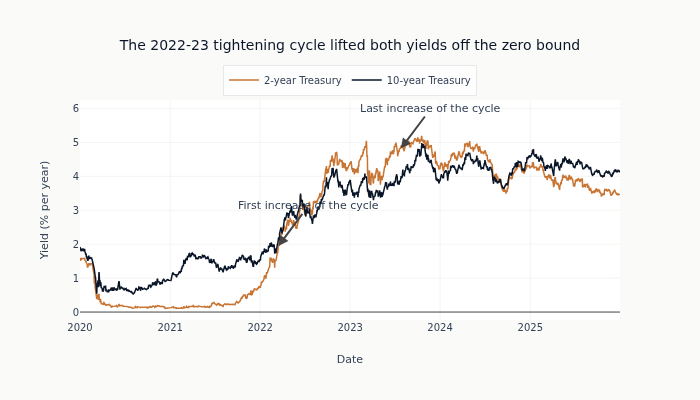

In [7]:
yields_recent = yields.filter(pl.col("timestamp") >= pl.lit(RECENT_START).str.to_date())
yields_pd = yields_recent.to_pandas()

fig = go.Figure()
for column, label, color in [
    ("dgs2", "2-year Treasury", COLORS["copper"]),
    ("dgs10", "10-year Treasury", COLORS["blue"]),
]:
    fig.add_trace(
        go.Scatter(
            x=yields_pd["timestamp"],
            y=yields_pd[column],
            mode="lines",
            name=label,
            line=dict(color=color, width=1.5),
        )
    )
for date, label in [
    ("2022-03-16", "First increase of the cycle"),
    ("2023-07-26", "Last increase of the cycle"),
]:
    # An event outside the window this chart opens on has nothing to point at.
    at_date = yields_pd.loc[yields_pd["timestamp"].astype(str) == date, "dgs2"]
    if at_date.empty:
        continue
    fig.add_annotation(
        x=date,
        y=float(at_date.iloc[0]),
        text=label,
        showarrow=True,
        arrowhead=2,
        ax=30,
        ay=-40,
    )
fig.update_layout(
    title="The 2022-23 tightening cycle lifted both yields off the zero bound",
    xaxis_title="Date",
    yaxis_title="Yield (% per year)",
    height=400,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
)
show_plotly_with_alt(
    fig,
    "Line chart of the two-year and ten-year Treasury yields from 2020, both starting near zero, rising steeply through 2022 and 2023 to around five percent, and easing afterwards. Two annotations mark the first and last policy increases of the cycle.",
)

## 4. The VIX

The VIX is the volatility the S&P 500 option market is pricing for the next thirty days,
quoted as an annualized percentage. It is not a forecast anyone made; it is what has to be
assumed about future volatility for the observed option prices to be fair. It rises when
demand for protection rises, which is why it is read as a measure of how frightened the market
is rather than of how volatile it has been.

In [8]:
vix = macro.select("timestamp", "vixcls").drop_nulls()
print(f"Observations: {len(vix):,}")
print(f"Mean over the full history: {vix['vixcls'].mean():.1f}")
print(f"Highest value in the history: {vix['vixcls'].max():.1f}")
print(f"Date it was reached: {vix.filter(pl.col('vixcls') == vix['vixcls'].max())['timestamp'][0]}")

Observations: 9,495
Mean over the full history: 19.8
Highest value in the history: 82.7
Date it was reached: 2020-03-16


The two reference lines mark the levels the market conventionally treats as the boundary
between a calm regime, an unsettled one and a frightened one. They are conventions rather than
thresholds anything is computed from, and the point of drawing them is that the series spends
most of its life below the first and only days at a time above the second.

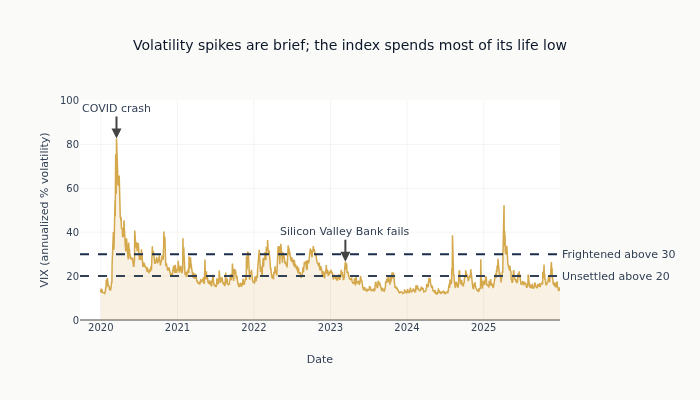

In [9]:
vix_recent = vix.filter(pl.col("timestamp") >= pl.lit(RECENT_START).str.to_date())
vix_pd = vix_recent.to_pandas()

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=vix_pd["timestamp"],
        y=vix_pd["vixcls"],
        mode="lines",
        name="VIX",
        line=dict(color=COLORS["amber"], width=1.5),
        fill="tozeroy",
        fillcolor="rgba(212, 168, 75, 0.15)",  # translucent COLORS["amber"]
    )
)
for level, label, color in [
    (20, "Unsettled above 20", COLORS["neutral"]),
    (30, "Frightened above 30", COLORS["slate"]),
]:
    fig.add_hline(
        y=level,
        line_dash="dash",
        line_color=color,
        annotation_text=label,
        annotation_position="right",
    )
for date, label in [
    ("2020-03-16", "COVID crash"),
    ("2023-03-13", "Silicon Valley Bank fails"),
]:
    at_date = vix_pd.loc[vix_pd["timestamp"].astype(str) == date, "vixcls"]
    if at_date.empty:
        continue
    fig.add_annotation(
        x=date, y=float(at_date.iloc[0]), text=label, showarrow=True, arrowhead=2, ax=0, ay=-30
    )
fig.update_layout(
    title="Volatility spikes are brief; the index spends most of its life low",
    xaxis_title="Date",
    yaxis_title="VIX (annualized % volatility)",
    height=400,
    showlegend=False,
    margin=dict(r=140),
)
show_plotly_with_alt(
    fig,
    "Filled line chart of the VIX from 2020, with dashed rules at twenty and thirty. The series spends most of its length below twenty, with brief tall spikes annotated at the COVID crash and the failure of Silicon Valley Bank.",
)

## 5. The yield curve spread, and checking a derived column

Subtract the two-year yield from the ten-year and you have the slope of the curve. It is
normally positive, because lending for longer usually earns more. When it goes negative the
curve is **inverted**: the market is paying more to lend for two years than for ten, which
happens when it expects the policy rate to be cut substantially before the ten years are up.
Every US recession since 1970 has been preceded by an inversion, which is why the spread is
watched even though the lead time between the two has ranged from months to years.

The panel carries this quantity twice. `t10y2y` is FRED's own published spread series, and
`YIELD_CURVE_SLOPE` is computed in this repository from the formula its metadata declares.
Two columns for one quantity is worth a check rather than a comment, because a derived column
whose formula has drifted from its description is invisible until something built on it is
wrong.

In [10]:
declared_formula = meta.filter(pl.col("series") == "YIELD_CURVE_SLOPE")["formula"][0]
print(f"YIELD_CURVE_SLOPE is declared as: {declared_formula}")

agreement = macro.select(
    (pl.col("t10y2y") - (pl.col("dgs10") - pl.col("dgs2"))).abs().alias("gap_to_recomputed"),
    (pl.col("t10y2y") - pl.col("YIELD_CURVE_SLOPE")).abs().alias("gap_to_derived_column"),
).drop_nulls()
print(
    f"Largest gap between FRED's spread and 10Y minus 2Y: {agreement['gap_to_recomputed'].max():.2e}"
)
print(
    f"Largest gap between FRED's spread and the derived column: {agreement['gap_to_derived_column'].max():.2e}"
)

YIELD_CURVE_SLOPE is declared as: DGS10 - DGS2
Largest gap between FRED's spread and 10Y minus 2Y: 8.88e-16
Largest gap between FRED's spread and the derived column: 8.88e-16


Both gaps are at the limit of floating-point precision, so the two columns are the same
quantity and either may be used. Where they had disagreed, the recomputation from `dgs10` and
`dgs2` is the one to trust, because it is the one whose inputs are in the panel.

In [11]:
spread = macro.select("timestamp", "t10y2y").drop_nulls()
inverted_days = spread.filter(pl.col("t10y2y") < 0).height
print(f"Days in the full history with an inverted curve: {inverted_days:,} of {len(spread):,}")
print(f"Share of the history inverted: {inverted_days / len(spread):.1%}")

Days in the full history with an inverted curve: 1,467 of 9,495
Share of the history inverted: 15.5%


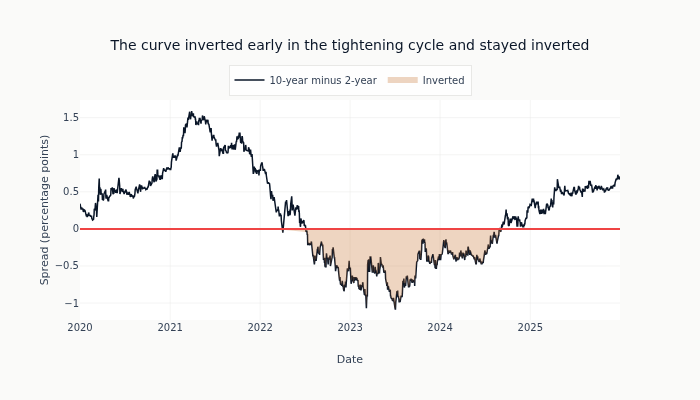

In [12]:
spread_recent = spread.filter(pl.col("timestamp") >= pl.lit(RECENT_START).str.to_date())
spread_pd = spread_recent.to_pandas()
inverted = spread_pd[spread_pd["t10y2y"] < 0]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=spread_pd["timestamp"],
        y=spread_pd["t10y2y"],
        mode="lines",
        name="10-year minus 2-year",
        line=dict(color=COLORS["blue"], width=1.5),
    )
)
if len(inverted) > 0:
    fig.add_trace(
        go.Scatter(
            x=inverted["timestamp"],
            y=inverted["t10y2y"],
            mode="none",
            fill="tozeroy",
            fillcolor="rgba(200, 117, 51, 0.3)",  # translucent COLORS["copper"]
            name="Inverted",
        )
    )
fig.add_hline(y=0, line_color=COLORS["negative"], line_width=2)
fig.update_layout(
    title="The curve inverted early in the tightening cycle and stayed inverted",
    xaxis_title="Date",
    yaxis_title="Spread (percentage points)",
    height=400,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
)
show_plotly_with_alt(
    fig,
    "Line chart of the ten-year minus two-year Treasury spread from 2020, crossing below the zero line in mid-2022 and staying below it into 2024, with the negative region shaded.",
)

## 6. Mixed frequencies, and why the row counts do not show them

Counting non-null rows is the obvious way to ask how often a series is published, and on this
panel it gives the wrong answer for every series. The monthly unemployment rate has a value on
every one of the panel's calendar days, and so does quarterly GDP: the file was built by
carrying each series' last released value forward onto the daily grid, so the nulls that would
have revealed the cadence are already gone.

What the fill leaves intact is how often the value *changes*. A monthly series carried forward
holds one value for a month at a time whatever grid it sits on, so counting the changes
recovers the release clock. It recovers a lower bound on it, strictly: two consecutive releases
that print the same number look like one, which matters for a coarsely rounded series and not
for a price.

In [13]:
cadence = pl.DataFrame(
    {
        "series": [c for c in macro.columns if c != "timestamp"],
        "rows_with_a_value": [
            int(macro[c].is_not_null().sum()) for c in macro.columns if c != "timestamp"
        ],
        "value_changes": [
            int((macro[c] != macro[c].shift(1)).sum()) for c in macro.columns if c != "timestamp"
        ],
    }
).join(meta.select(pl.col("series"), "native_frequency", "description"), on="series", how="left")

years = (last_date - first_date).days / 365.25
cadence = cadence.with_columns(changes_per_year=(pl.col("value_changes") / years).round(1)).sort(
    "changes_per_year", descending=True
)
cadence.select("series", "description", "native_frequency", "rows_with_a_value", "changes_per_year")

series,description,native_frequency,rows_with_a_value,changes_per_year
str,str,str,i64,f64
"""vixcls""","""VIX Volatility Index""","""daily""",9495,251.2
"""dgs7""","""7-Year Treasury Constant Matur…","""daily""",9495,231.4
"""dgs10""","""10-Year Treasury Constant Matu…","""daily""",9495,230.5
"""dgs30""","""30-Year Treasury Constant Matu…","""daily""",9495,230.1
"""dgs20""","""20-Year Treasury Constant Matu…","""daily""",9495,229.5
…,…,…,…,…
"""cpiaucsl""","""CPI All Urban Consumers""","""monthly""",9497,11.7
"""unrate""","""Unemployment Rate""","""monthly""",9497,8.8
"""civpart""","""Labor Force Participation""","""monthly""",9497,8.5


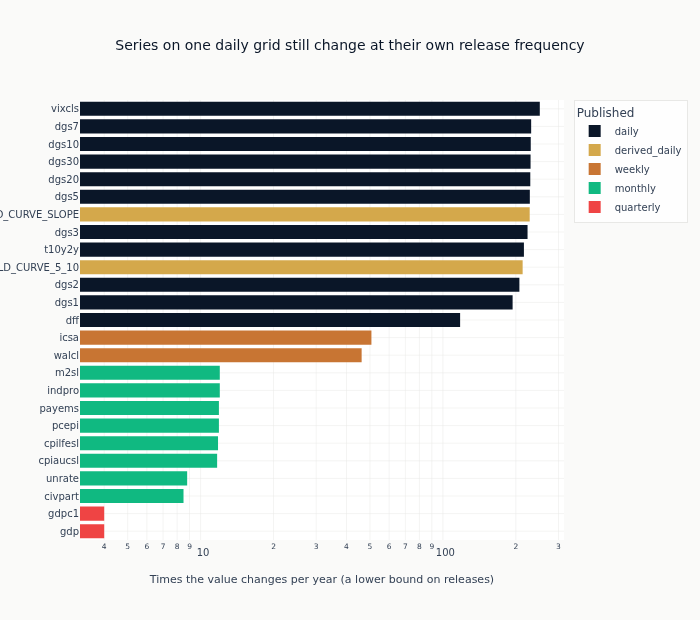

In [14]:
fig = px.bar(
    cadence.drop_nulls("native_frequency").to_pandas(),
    x="changes_per_year",
    y="series",
    color="native_frequency",
    orientation="h",
    hover_name="description",
    title="Series on one daily grid still change at their own release frequency",
    labels={
        "changes_per_year": "Times the value changes per year (a lower bound on releases)",
        "series": "",
        "native_frequency": "Published",
    },
    log_x=True,
)
fig.update_layout(height=620, yaxis=dict(categoryorder="total ascending"))
show_plotly_with_alt(
    fig,
    "Horizontal bar chart, on a logarithmic axis, of how often each series changes value per year, coloured by its published frequency. The bars separate into distinct groups matching daily, weekly, monthly and quarterly publication.",
)

The bars separate into groups that match the metadata's `native_frequency` without being told
it: the business-daily series in the hundreds of changes a year, the weekly one near fifty, the
monthly ones near ten and the quarterly ones near four. Reading the same panel by row count
would have said all of them were daily.

The unemployment rate is the case where the lower bound bites, and it is worth seeing rather
than taking on trust. It is published monthly and rounded to a tenth of a percentage point, so
in a year of twelve releases the printed value repeats often enough that the change count comes
in well under twelve.

### Why forward fill, and what it costs

The test a fill has to pass is not which method it uses; it is which observations the value on
a date was computed from. Carrying the last released value forward passes because it reads
only what was already out. So does any trailing calculation on released values - an average of
the last three releases, an exponentially weighted mean, a forecast fitted on history alone.

What fails is anything that reaches forward. Interpolating between two monthly readings puts a
value on the tenth of the month computed partly from the reading published on the thirtieth.
A backward fill does it outright. A centred moving average takes half its window from the
future, and a seasonal adjustment estimated over the whole sample takes its factors from
every year in it, including the ones after the date being adjusted.

What forward fill costs is that the panel says nothing about *when* the value it carries became
known. The unemployment rate for March is published in early April, so a row dated 15 March
carrying March's rate is showing a number nobody had. That gap is a release lag, and closing it
is the subject of [`07_macro_data_alignment`](07_macro_data_alignment.ipynb).

In [15]:
unrate_2024 = macro.select("timestamp", "unrate").filter(pl.col("timestamp").dt.year() == 2024)
by_month = (
    unrate_2024.group_by(pl.col("timestamp").dt.month().alias("month"))
    .agg(
        pl.col("timestamp").min().alias("first_day"),
        pl.col("unrate").n_unique().alias("distinct_values_in_month"),
        pl.col("unrate").first().alias("rate"),
    )
    .sort("month")
)
changes = int((unrate_2024["unrate"] != unrate_2024["unrate"].shift(1)).sum())
print(f"Rows in 2024: {len(unrate_2024)}")
print(f"Months, and so releases, in 2024: {len(by_month)}")
print(f"Days on which the printed rate changed: {changes}")
by_month

Rows in 2024: 366
Months, and so releases, in 2024: 12
Days on which the printed rate changed: 6


month,first_day,distinct_values_in_month,rate
i8,date,u32,f64
1,2024-01-01,1,3.7
2,2024-02-01,1,3.9
3,2024-03-01,1,3.9
4,2024-04-01,1,3.9
5,2024-05-01,1,3.9
…,…,…,…
8,2024-08-01,1,4.2
9,2024-09-01,1,4.1
10,2024-10-01,1,4.1


## 7. Three series together

Read separately, each of the three charts above is a story about one market. Read together on
a shared time axis, they are one story: policy tightened, the curve inverted in anticipation of
the cuts that tightening implies, and volatility spiked at the two moments when the market
doubted the path.

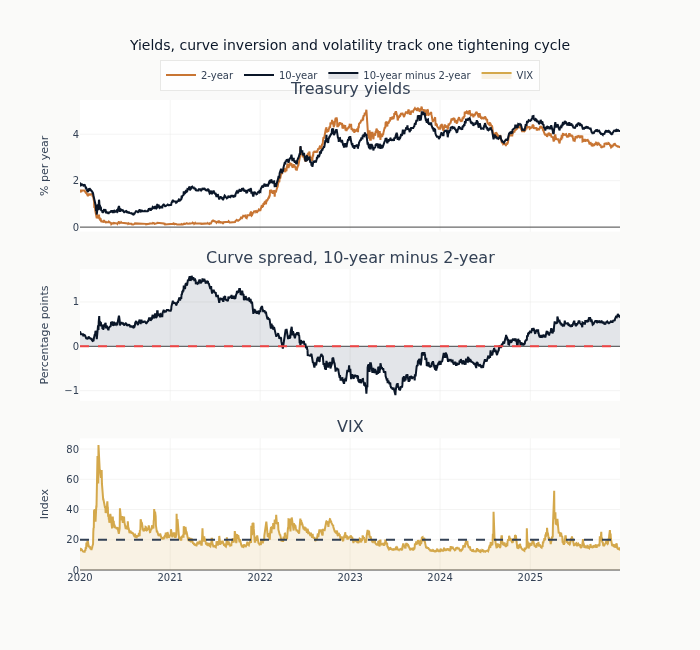

In [16]:
recent = macro.filter(pl.col("timestamp") >= pl.lit(RECENT_START).str.to_date()).to_pandas()

fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    subplot_titles=(
        "Treasury yields",
        "Curve spread, 10-year minus 2-year",
        "VIX",
    ),
    vertical_spacing=0.08,
)
fig.add_trace(
    go.Scatter(
        x=recent["timestamp"],
        y=recent["dgs2"],
        mode="lines",
        name="2-year",
        line=dict(color=COLORS["copper"]),
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=recent["timestamp"],
        y=recent["dgs10"],
        mode="lines",
        name="10-year",
        line=dict(color=COLORS["blue"]),
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=recent["timestamp"],
        y=recent["t10y2y"],
        mode="lines",
        name="10-year minus 2-year",
        line=dict(color=COLORS["blue"]),
        fill="tozeroy",
        fillcolor="rgba(26, 45, 74, 0.12)",  # translucent COLORS["slate"]
    ),
    row=2,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["negative"], row=2, col=1)
fig.add_trace(
    go.Scatter(
        x=recent["timestamp"],
        y=recent["vixcls"],
        mode="lines",
        name="VIX",
        line=dict(color=COLORS["amber"]),
        fill="tozeroy",
        fillcolor="rgba(212, 168, 75, 0.15)",  # translucent COLORS["amber"]
    ),
    row=3,
    col=1,
)
fig.add_hline(y=20, line_dash="dash", line_color=COLORS["neutral"], row=3, col=1)
fig.update_yaxes(title_text="% per year", row=1, col=1)
fig.update_yaxes(title_text="Percentage points", row=2, col=1)
fig.update_yaxes(title_text="Index", row=3, col=1)
fig.update_layout(
    height=650,
    title_text="Yields, curve inversion and volatility track one tightening cycle",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
)
show_plotly_with_alt(
    fig,
    "Three stacked panels sharing a time axis from 2020: Treasury yields, the ten-year minus two-year spread with a zero line, and the VIX with a rule at twenty.",
)

## Key Takeaways

1. Establish what one row of a panel means before computing anything from it. This one is on a
   calendar-day grid, weekends included, which is not the grid any of its sources publishes on.
2. A row count does not tell you how often a series is published once the panel has been
   forward-filled. Counting how often the value changes recovers a lower bound on each source's
   release clock, which is enough to sort daily from weekly from monthly, and is short of the
   true count wherever consecutive releases print the same rounded number.
3. What makes a fill safe is that the value on a date was computed only from observations
   already released by that date. Forward fill qualifies, and so does any trailing average or
   causal forecast. Interpolation, backward fill, a centred window and a whole-sample seasonal
   adjustment all reach forward, and none of them will announce that they did.
4. Forward fill still leaves the release lag unhandled: the value it carries on a given date is
   often one the market had not yet been told. That is a separate correction and it is where
   the next notebook starts.
5. Where a panel carries a quantity twice, once as published and once as derived, check the
   derived column against the formula its metadata declares rather than trusting the name.

## Optional: keeping the panel current

The shipped parquet is a snapshot and is sufficient for every notebook in this book. For a
live pipeline, `ml4t-data` wraps the FRED API: `MacroDataManager` downloads and reloads the
Treasury curve and derives the curve slope and a regime label from it, and `FREDProvider`
fetches any series by its FRED identifier. Both need a free API key from
[fred.stlouisfed.org](https://fred.stlouisfed.org/docs/api/api_key.html).

```python
from ml4t.data.macro import MacroDataManager
from ml4t.data.providers.fred import FREDProvider

manager = MacroDataManager()
manager.download_treasury_yields()   # fetch the curve
manager.get_yield_curve_slope()      # 10-year minus 2-year
manager.get_regime()                 # the regime label derived from the slope

provider = FREDProvider()
provider.fetch_ohlcv("UMCSENT", start="2020-01-01")   # consumer sentiment
```